<a href="https://colab.research.google.com/github/NSF-DARSE/YolktoFeed/blob/main/JupyterNotebook/liverHEDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import sys

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [2]:
path = "/content/drive/Shareddrives/SCIPE-DARSE/Research Software Engineers (RSE)/Abhin/Projects/Carl Schmidt"
sys.path.append(path)

In [3]:
df_base = pd.read_csv(path+"/Liver_HEIDI_complete_ensembl_symbol.csv")

In [4]:
df_base.shape

(24869, 108)

In [5]:
# finding last row with valid gene symbol
gene_list_last_index = (df_base["Gene Symbol"] == "-").idxmax()

## Trucating till the valid gene name

In [6]:
#truncating till that row
df = df_base.iloc[:gene_list_last_index]
df = df.drop(columns=["Ensembl Gene ID"])
df

,Gene Symbol,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
0,ZZZ3,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,5.040800,3.031530,2.721210,...,0.970587,1.66351,1.636580,2.459220,4.893390,2.489600,3.19717,1.468440,2.091560,0.187683
1,ZYX,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,33.385700,27.918300,34.052300,...,13.140900,24.40290,25.381200,28.666700,34.741500,22.507700,29.35630,25.152600,34.865400,12.079700
2,ZXDC,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,2.900180,2.161720,2.230180,...,0.945374,1.22140,1.271560,2.263090,2.274030,1.651320,2.59244,2.715000,2.818080,0.710741
3,ZW10,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,9.869820,6.426870,5.543910,...,2.026740,3.13406,4.484710,5.776710,8.311750,4.391920,6.41727,4.316070,5.518810,1.944010
4,ZUFSP,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,4.454180,3.496990,2.421560,...,2.675900,1.74104,1.222440,3.358820,3.351070,2.998520,2.41147,1.658470,2.003540,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,0.056601,0.067055,0.061017,...,0.172556,0.00000,0.131267,0.230045,0.594857,0.254973,0.22188,0.201177,0.596807,0.095215
14461,A2ML4,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,664.186000,492.456000,1092.230000,...,211.638000,641.81200,604.835000,1026.430000,1004.110000,480.376000,1000.24000,778.891000,1191.370000,394.840000
14462,A2ML2,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,283.293000,169.966000,165.030000,...,130.653000,193.07000,301.891000,275.247000,395.356000,316.083000,156.38600,128.938000,186.548000,81.135700
14463,A1CF,22.040600,55.038200,26.661900,96.158400,26.078800,69.539400,111.482000,104.168000,76.200500,...,15.616700,37.06100,14.489100,36.690700,35.393500,20.619700,48.11020,28.213400,27.961700,4.667240


Checks to the implemented
- Test is the all values from column 1 df.iloc[:,1:] to the right is numbers
- Test if column name follows the same pattern
- While omitting based on average, see if any value has any spike on some days

## Adding a column for average and variance value of gene expression

In [7]:
# Adding a column for average gene expression across all days and all chikens for prelim analysis
df.insert(1, "avg_gene_expr", df.iloc[:, 1:].sum(axis=1)/(df.shape[1]-1))
df.insert(2, "sigma", df.iloc[:,1:].var(axis=1))

In [8]:
df

,Gene Symbol,avg_gene_expr,sigma,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
0,ZZZ3,3.622199,4.078277,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,5.040800,...,0.970587,1.66351,1.636580,2.459220,4.893390,2.489600,3.19717,1.468440,2.091560,0.187683
1,ZYX,28.979918,92.037086,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,33.385700,...,13.140900,24.40290,25.381200,28.666700,34.741500,22.507700,29.35630,25.152600,34.865400,12.079700
2,ZXDC,2.306640,1.159855,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,2.900180,...,0.945374,1.22140,1.271560,2.263090,2.274030,1.651320,2.59244,2.715000,2.818080,0.710741
3,ZW10,6.449800,8.820332,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,9.869820,...,2.026740,3.13406,4.484710,5.776710,8.311750,4.391920,6.41727,4.316070,5.518810,1.944010
4,ZUFSP,3.944223,5.608118,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,4.454180,...,2.675900,1.74104,1.222440,3.358820,3.351070,2.998520,2.41147,1.658470,2.003540,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.295477,0.036620,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,0.056601,...,0.172556,0.00000,0.131267,0.230045,0.594857,0.254973,0.22188,0.201177,0.596807,0.095215
14461,A2ML4,663.624438,150677.470732,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,664.186000,...,211.638000,641.81200,604.835000,1026.430000,1004.110000,480.376000,1000.24000,778.891000,1191.370000,394.840000
14462,A2ML2,210.725798,8557.568605,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,283.293000,...,130.653000,193.07000,301.891000,275.247000,395.356000,316.083000,156.38600,128.938000,186.548000,81.135700
14463,A1CF,52.387588,1164.264418,22.040600,55.038200,26.661900,96.158400,26.078800,69.539400,111.482000,...,15.616700,37.06100,14.489100,36.690700,35.393500,20.619700,48.11020,28.213400,27.961700,4.667240


In [10]:
#Basic stats on average gene expression levels with their corresponding sigma
print("number of Genes and max variance less than 1e-6:\t", df.loc[df.iloc[:,1] < 1e-6, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,1] < 1e-6, df.columns[2]].max())
print("number of Genes and max variance less than 1e-4:\t", df.loc[df.iloc[:,1] < 1e-4, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,1] < 1e-4, df.columns[2]].max())
print("number of Genes and max variance less than 1e-2:\t", df.loc[df.iloc[:,1] < 1e-2, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,1] < 1e-2, df.columns[2]].max())
print("number of Genes and max variance less than 1e-1:\t", df.loc[df.iloc[:,1] < 1e-1, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,1] < 1e-1, df.columns[2]].max())

number of Genes and max variance less than 1e-6:	 856 	 0.0
number of Genes and max variance less than 1e-4:	 861 	 1.0162009896760454e-06
number of Genes and max variance less than 1e-2:	 2014 	 0.007519074558599177
number of Genes and max variance less than 1e-1:	 3230 	 0.425126707757173


In [11]:
# Printing some Values in between 1e-6 and 1e-4
df.loc[(df.iloc[:,1] > 1e-6) & (df.iloc[:,1] < 1e-4), df.columns[0:3]]
#df.iloc[353,0:2]

,Gene Symbol,avg_gene_expr,sigma
5046,OTOG,0.000090,8.554998e-07
6660,MIR1688,0.000092,8.807185e-07
8808,KCNA4,0.000098,1.016201e-06
9349,HOXC11,0.000042,1.855530e-07
11837,CSMD1,0.000043,1.955104e-07


## Omitting gene with average expression less than 1e-4

In [12]:
df = df[df.iloc[:,1] >= 1e-4]
df

,Gene Symbol,avg_gene_expr,sigma,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
0,ZZZ3,3.622199,4.078277,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,5.040800,...,0.970587,1.66351,1.636580,2.459220,4.893390,2.489600,3.19717,1.468440,2.091560,0.187683
1,ZYX,28.979918,92.037086,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,33.385700,...,13.140900,24.40290,25.381200,28.666700,34.741500,22.507700,29.35630,25.152600,34.865400,12.079700
2,ZXDC,2.306640,1.159855,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,2.900180,...,0.945374,1.22140,1.271560,2.263090,2.274030,1.651320,2.59244,2.715000,2.818080,0.710741
3,ZW10,6.449800,8.820332,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,9.869820,...,2.026740,3.13406,4.484710,5.776710,8.311750,4.391920,6.41727,4.316070,5.518810,1.944010
4,ZUFSP,3.944223,5.608118,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,4.454180,...,2.675900,1.74104,1.222440,3.358820,3.351070,2.998520,2.41147,1.658470,2.003540,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.295477,0.036620,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,0.056601,...,0.172556,0.00000,0.131267,0.230045,0.594857,0.254973,0.22188,0.201177,0.596807,0.095215
14461,A2ML4,663.624438,150677.470732,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,664.186000,...,211.638000,641.81200,604.835000,1026.430000,1004.110000,480.376000,1000.24000,778.891000,1191.370000,394.840000
14462,A2ML2,210.725798,8557.568605,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,283.293000,...,130.653000,193.07000,301.891000,275.247000,395.356000,316.083000,156.38600,128.938000,186.548000,81.135700
14463,A1CF,52.387588,1164.264418,22.040600,55.038200,26.661900,96.158400,26.078800,69.539400,111.482000,...,15.616700,37.06100,14.489100,36.690700,35.393500,20.619700,48.11020,28.213400,27.961700,4.667240


## New dataframe with values average over days

In [16]:
# First make a dictionary with col name corresponding to days
groups = {}
for col in df.columns[3:]:
  day = col.split("_")[-1]
  # If day not in dict, intializes, otherwise append col to that list
  groups.setdefault(day, []).append(col)
print(len(groups["4"]), groups["4"])

df_days = pd.DataFrame()

11 ['1650_summed_TPM_4', '1651_summed_TPM_4', '1653_summed_TPM_4', '1654_summed_TPM_4', '1655_summed_TPM_4', '1656_summed_TPM_4', '1657_summed_TPM_4', '1671_summed_TPM_4', '1672_summed_TPM_4', '1673_summed_TPM_4', '1776_summed_TPM_4']


In [20]:
# Add gene symbols as first column
df_days = pd.DataFrame({df.columns[0]: df.iloc[:,0]})

# Find the mean and variance for days
for day, cols in groups.items():
  df_days[f"day{day}_avg"] = df[cols].mean(axis=1)
  df_days[f"day{day}_sigma"] = df[cols].var(axis=1)
df_days

,Gene Symbol,day4_avg,day4_sigma,day6_avg,day6_sigma,day8_avg,day8_sigma,day10_avg,day10_sigma,day12_avg,day12_sigma,day14_avg,day14_sigma,day16_avg,day16_sigma,day18_avg,day18_sigma,day20_avg,day20_sigma
0,ZZZ3,4.225709,2.517081,0.953764,0.236265,4.278279,2.169685,4.195737,3.731420,3.034347,1.728714,5.011790,0.892738,5.130389,9.468639,3.784953,1.347033,2.150913,1.377910
1,ZYX,36.047936,128.615525,19.705650,50.019128,29.822050,29.563380,30.575958,70.740881,29.802075,40.237388,30.175145,37.592915,32.275750,232.706551,25.898283,62.448888,27.205017,74.934826
2,ZXDC,2.607343,0.948288,0.777705,0.099151,2.712533,0.307017,2.360046,0.334795,2.362605,1.060999,2.876152,0.497583,2.983429,3.308391,2.311302,0.364755,1.841165,0.499996
3,ZW10,7.528290,5.357893,2.225634,0.790829,7.726521,2.562777,6.723687,4.861016,6.354158,6.124200,8.891599,3.149292,8.195503,21.528411,6.118378,2.442329,4.577793,3.223964
4,ZUFSP,2.978055,0.426497,1.061303,0.310436,4.806378,2.082001,3.969455,1.846055,3.463997,3.029641,5.564387,3.310879,5.995768,13.203438,5.555640,4.883451,2.157520,0.694160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.122044,0.006417,0.082118,0.001656,0.258182,0.009369,0.289407,0.027268,0.425451,0.016768,0.396496,0.014947,0.397687,0.056705,0.425251,0.048323,0.256623,0.032031
14461,A2ML4,551.419455,70636.710641,226.178283,13908.780751,594.449333,77057.541869,759.427500,56240.779358,513.685917,36339.196924,819.509727,64960.204381,1024.191250,560689.746632,720.742750,48419.017177,766.655750,93687.188298
14462,A2ML2,196.006000,2076.804730,77.918633,2032.221987,190.413658,2479.902551,207.086750,2906.735239,184.406167,3459.627833,297.231727,4893.783380,225.701117,13326.146568,298.123917,5467.390572,225.626392,9473.869084
14463,A1CF,68.160064,1235.826170,10.178156,6.156964,39.292748,800.760427,82.992950,456.928781,37.565825,1060.531148,72.911318,557.412911,62.248866,829.201585,67.366875,1217.030397,33.796170,428.364901


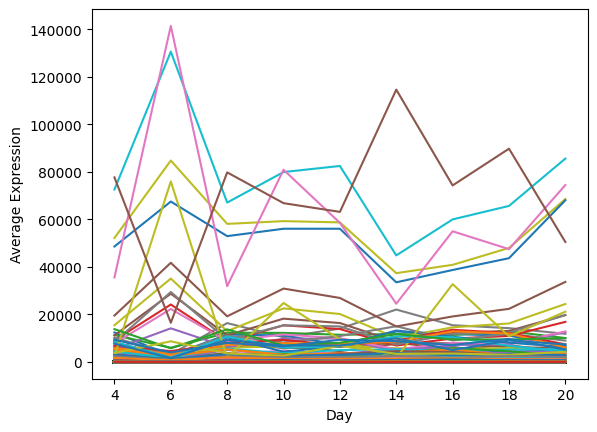

In [23]:
import matplotlib.pyplot as plt

#iterating over the rows or essentially genes
for _, row in df_days.iterrows():
  x = []
  y = []
  for day, cols in groups.items():
    x.append(int(day))
    y.append(row[f"day{day}_avg"])
  plt.plot(x,y)
  plt.xlabel("Day")
  plt.ylabel("Average Expression")

In [49]:
#col_new_names = [name.split('_')[0] +'_' +name.split('_')[3] for name in df.columns[1:]]
#col_new_names[:5]
#df.columns = list(df.columns[:1]) + col_new_names
#df

In [50]:
chicken_tag = [tag_name.split('_')[0] for tag_name in df.columns[2:]]
list_days = list(set([int(day.split('_')[-1]) for day in df.columns[2:]]))

In [52]:
list_days.sort()
list_days

[4, 6, 8, 10, 12, 14, 16, 18, 20]

In [53]:
df_day4 = df.loc[:,["Gene Symbol"] + df.filter(regex=r"_4$").columns.tolist()]

In [54]:
df_day4

,Gene Symbol,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,1673_summed_TPM_4,1776_summed_TPM_4
0,ZZZ3,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,5.040800,3.031530,2.721210,3.941250,3.905400
1,ZYX,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,33.385700,27.918300,34.052300,57.311000,23.525900
2,ZXDC,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,2.900180,2.161720,2.230180,4.596810,1.855440
3,ZW10,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,9.869820,6.426870,5.543910,8.634280,6.712340
4,ZUFSP,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,4.454180,3.496990,2.421560,2.140630,2.766770
...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,0.056601,0.067055,0.061017,0.105077,0.153445
14461,A2ML4,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,664.186000,492.456000,1092.230000,723.640000,842.732000
14462,A2ML2,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,283.293000,169.966000,165.030000,182.840000,216.004000
14463,A1CF,22.040600,55.038200,26.661900,96.158400,26.078800,69.539400,111.482000,104.168000,76.200500,114.381000,48.011900


In [14]:
#df_day6 = df.loc[:,["Gene Symbol"] + df.filter(regex=r"_6$").columns.tolist()]
#df_day6

In [55]:
#df